<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Intro to AI Agents<a class="tocSkip">

In this notebook we will see how to build **AI Agents** via the `LangGraph` library.

The focus is on making Agent behavior explicit and testable (_as opposed to a single LLM prompt_).

**Study case:** We will build an Agent that answers scientific questions.

# Setup

On **Colab**, allow GPU usage:

    Connect → Change runtime type → T4 GPU

In [1]:
#!pip install --quiet -U ipywidgets==8.1.8 arxiv python-dotenv huggingface_hub transformers mistral-common==1.8.6 accelerate langchain_openai langchain_core langgraph langgraph-prebuilt

In [2]:
import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(url).text
exec(colab)

Repository:
https://github.com/AstroStat-Academy/astrostat-school-7.git

Branch:
main

Working in:
/content/astrostat-school-7/AI_Agents

Content:
	 ['AI_Agents.ipynb', 'images']


In [3]:
import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

Imported matplotlib.
Imported seaborn.
Plotting style set.


# What is an Agent?

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

An **Artificial Intelligence (AI) Agent** is a program that pairs a Large Language Model (LLM) with the ability to take actions.

Instead of returning a single answer, the Agent works in a **Reasoning and Acting (ReAct)** loop:
- it **reasons** about the task,
- takes an **action**,
- **observes** the result, and
- **decides** the next step.

</div>

There are 2 defining aspects:

**<u>The LLM is the reasoning engine</u>**

<div style="margin-left: 2em;">

At each step, it reads the task and the results collected so far.<br>
Based on that, it **decides** what to do next: answer directly, or take an action.

</div>

**<u>Tools go beyond text generation</u>**

<div style="margin-left: 2em;">

By itself, an LLM is a **text** generator: it can only turn input text into output text.<br>
A **tool** is a function the Agent can call to perform one such action (_e.g., search the web, run code, or read files_).<br>

</div>

Endowing the LLM with tools is _what turns_ a plain text generator into an Agent.

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/AI_Agents/images/fig_agent_anatomy_anim.gif?raw=1" width=800 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=800><center><br>
Figure 1. Anatomy of an AI Agent: 1 full loop of its interactions.
<br></center></td></tr></table>

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

**NOTE:** Beside the LLM and its tools, 2 more support components:
- **History** — the running list of messages (_task, tool calls, tool results_), which the LLM re-reads at each step of the loop.
- **Human-in-the-loop** [optional] — a person who reviews or approves the Agent's steps before they are executed.

</div>

# Use case

To showcase the advantages of Agents, we will try to answer the following query:

>_Explain how to constrain compact dark matter with time-varying quasar equivalent widths._

- first, with a simple **LLM**
- then, with an **Agent**


# Using an LLM

## How an LLM generates text

An LLM does not "know" the answer — it **samples** it, one token at a time.

At each step, the model **samples** the next token from a **probability distribution** over its vocabulary:

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/AI_Agents/images/fig0_distribution.png?raw=1" width=580 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=580><center><br>
Figure 2. Example next-token distribution over a toy astronomy vocabulary.
The model assigns a distinct probability to every candidate token; the next word is sampled from this distribution.
<br></center></td></tr></table>

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

Formally, at each step $t$ the model computes:

$$P(x_t \mid x_1, \dots, x_{t-1}, \text{prompt})$$

i.e., a probability for **every token in the vocabulary**, conditioned on:
- the **prompt**, and
- all the **tokens generated so far**.

</div>

The **temperature** ($T)$ is a _hyperparameter_ of the model, and reshapes the distribution before sampling:
- **Low $T$** $\rightarrow$ peaked distribution $\rightarrow$ the model almost always picks the highest-probability token (_deterministic_)
- **High $T$** $\rightarrow$ flat distribution $\rightarrow$ lower-probability tokens get more chances (_creative, but less reliable_)

<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/AI_Agents/images/fig1_temperature.png?raw=1" width=800 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=800><center><br>
Figure 3. Token probability distributions for a toy astronomy vocabulary at three temperatures.
At low $T$ the model concentrates mass on the top token; at high $T$ the distribution flattens and less likely tokens become reachable.
<br></center></td></tr></table>


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

<details>

<b><summary>[How T is used in the computation] (click here to expand)</summary></b>  

The model produces a vector of **logits** $z_i$ — one per vocabulary token.<br>
These are converted to probabilities via the **softmax** function:

$$p_i = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

where $T$ is the **temperature** — a parameter you control.<br>
The next token is then sampled from this distribution.

</details>
</div>

For **Agents** we want _deterministic_, _reproducible_ behavior, not creative variation $\rightarrow$ We will use $T = 0$.

## Local model vs. API

There are two ways to use a language model from Python:
- **run it locally** on your machine, or
- **call a remote API** where the model runs on someone else's server.

| | Local model | API |
|---|---|---|
| **Cost** | Free after download | Pay per token |
| **Privacy** | Data stays on your machine | Data sent to a third party |
| **Setup** | Heavier (~4–14 GB download) + GPU | Just an API key |
| **Speed** | Depends on your hardware | Fast, always-on |

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

**NOTE:** In the Agent section we will access the model only through OpenRouter.

</div>

## Calling a local model — Ministral

**<u>Load the model</u>**

We load **Ministral 3 3B Instruct** locally with `transformers`. This smaller model is designed for low-resource devices, and its weights download from Hugging Face on first use and are cached afterwards.

In [4]:
import torch
print('CUDA available?', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

CUDA available? True
GPU: Tesla T4


In [5]:
import torch
from transformers import AutoTokenizer, Mistral3ForConditionalGeneration

MODEL = "mistralai/Ministral-3-3B-Instruct-2512-BF16"

model = Mistral3ForConditionalGeneration.from_pretrained(
    MODEL,
    device_map="auto",
    dtype=torch.bfloat16,
    attn_implementation="sdpa",
)

"""bfloat16 keeps the model weights near 8 GB instead of about 16 GB in
float32. This leaves more room on a Colab GPU than the 7B model used before.

SDPA (Scaled Dot Product Attention) uses PyTorch's built-in optimized attention
backend to use efficient GPU attention kernels when the installed PyTorch/CUDA
stack supports them.""";

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

**<u>Build the prompt</u>**

We turn the role-tagged messages into the exact prompt format Ministral expects using the tokenizer's **chat template**, then tokenize it.

In [6]:
system = "You are a helpful astrophysics assistant."
user = "Explain how to constrain compact dark matter with time-varying quasar equivalent widths."

messages = [
    {"role": "system", "content": system},
    {"role": "user", "content": user},
]

In [7]:
tok = AutoTokenizer.from_pretrained(MODEL, fix_mistral_regex=True)

inputs = tok.apply_chat_template(
    messages,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device)
"""apply_chat_template renders the role-tagged messages into the exact
prompt string Ministral was trained on, then tokenizes it.
- add_generation_prompt=True appends the opening that cues the model to start its reply.
- return_dict=True keeps the token identifiers and attention mask together.
- return_tensors="pt" gives PyTorch tensors;""";

print('Number of input tokens:', inputs["input_ids"].shape[1])

tokenizer_config.json:   0%|          | 0.00/198k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/147k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Number of input tokens: 32


In [12]:
messages

[{'role': 'system', 'content': 'You are a helpful astrophysics assistant.'},
 {'role': 'user',
  'content': 'Explain how to constrain compact dark matter with time-varying quasar equivalent widths.'}]

In [13]:
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

model.generation_config.pad_token_id = tok.pad_token_id

out = model.generate(
    **inputs,
    max_new_tokens=60,
    do_sample=True,
)
"""Generate a deterministic continuation.

- pad_token sets a valid tokenizer padding token when the model has none.
- generation_config.pad_token_id prevents generate() from inferring the pad token at runtime.
- the tokenizer provides the input identifiers and attention mask together.
- do_sample=False uses greedy decoding, so the same prompt gives the same output."""

answer_ids = out[0, inputs["input_ids"].shape[1]:]   # keep only the newly generated tokens, not the prompt
print(tok.decode(answer_ids, skip_special_tokens=True).strip())

[transformers] Both `max_new_tokens` (=60) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Constraining compact dark matter (CDM) models using time-varying **quasar equivalent widths (EWs)** is an interesting approach, given the theoretical predictions for how dark matter's self-interaction strength (α) could modulate line strengths in active galactic nuclei (AGNs) through effects like


## Calling a remote model via API — OpenRouter

Local models are free to use, but sometimes we need larger models hosted by some **provider**.<br>
(_e.g., OpenAI, Mistral AI, Anthropic, Alibaba Cloud, etc._).

**<u>Obtaining an API key</u>**

In this lecture, we access models through **OpenRouter** — a service which connects to several providers.
>_OpenRouter provides limited token access to these models, but sufficient for this demonstration._

OpenRouter has its own **Application Programming Interface** (**API**) — To obtain an OpenRouter API key:

1. Create an account or sign in at [openrouter.ai](https://openrouter.ai/).<br>
2. Open the [API keys page](https://openrouter.ai/settings/keys).
3. Click **Create Key**, choose a name and an optional credit limit, then confirm.
4. **Copy the key** right away and store it as described below.

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

**WARNING:** The key is displayed only 1 time, at creation.

If you lose it, you <u>cannot</u> recover it $\rightarrow$ you must generate a new key.

</div>

**<u>Storing the API key</u>**

The **API key** is a secret string that identifies and authenticates you to a remote service.

For good manners, API keys shall <u>not</u> be part of the code.<br>
One way is to "hide" them in a `.env` file, then load them from there.

> _Place the OpenRouter key in a `.env` file in the same folder as this notebook._

Example content of the `.env` file:

```python
OPENROUTER_API_KEY="<your_openrouter_api_key_here>"
```

then load it with:

```python
from dotenv import load_dotenv
load_dotenv()
```

The key is now stored in a system variable:

```python
os.environ["OPENROUTER_API_KEY"]
```

In [14]:
import os
from dotenv import load_dotenv

load_dotenv();  # loads .env if present, skips if key already in system env


On **Colab**, use the Secrets manager instead (_left sidebar → 🔑 icon_). Add a secret named `OPENROUTER_API_KEY`, then load it with:

In [16]:
import sys

if "google.colab" in sys.modules:
    from google.colab import userdata

    os.environ["OPENROUTER_API_KEY"] = userdata.get("OPENROUTER_API_KEY")


In [17]:
if not os.getenv("OPENROUTER_API_KEY"):
    print("OPENROUTER_API_KEY not found in env.")
else:
    print("OPENROUTER_API_KEY has been set.")


OPENROUTER_API_KEY has been set.


**<u>Run the model</u>**

The `langchain_openai` library sends the prompt to OpenRouter when we set its _API key_ and _base address_.

In [18]:
%%time
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="openai/gpt-5.4-mini",  # <-- asking for an OpenAI model, here
    api_key=os.getenv("OPENROUTER_API_KEY"),
    openai_api_base="https://openrouter.ai/api/v1",
    temperature=0,
    max_completion_tokens=512,
)

response = llm.invoke("Explain how to constrain compact dark matter with time-varying quasar equivalent widths.")
print(response.content)


You can constrain **compact dark matter**—especially **MACHOs** or other compact lenses—by looking for **gravitational microlensing** of quasars and, in particular, how it changes the **equivalent width (EW)** of quasar spectral lines over time.

## Core idea

A quasar has at least two relevant emitting regions:

- **Continuum source**: very small, from the accretion disk
- **Broad-line region (BLR)**: much larger, emits broad emission lines

A compact lens (a star, primordial black hole, etc.) has an Einstein radius that can be comparable to the continuum region but usually smaller than or comparable to the BLR only in special cases. Because of that size mismatch:

- the **continuum** can be strongly magnified or demagnified by microlensing
- the **broad emission lines** are usually much less affected

That means the **equivalent width**
\[
\mathrm{EW} = \frac{\text{line flux}}{\text{continuum flux per unit wavelength}}
\]
can vary if only the continuum is lensed.

If the continuum is

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

**NOTES:**

- The `temperature` parameter allows to set how **deterministic** we want the LLM to be<br>

    &emsp;&emsp; **lower** temperature $\leftrightarrow$ more **deterministic**

    &emsp;&emsp; **higher** temperature [max=1] $\leftrightarrow$ more **stochastic**

    Usually, in an Agent framework, we wish to have **low** temperature since we need a more systematic behavior

- Notice that `llm` is a `langchain_openai` object.

    This has several methods we will need later, such as:
    ```python
    llm.bind_tools()
    ```
</div>


# Tools

We now wish to empower our LLM by providing it with a tool to **search for papers**.

In particular, we will use the `arXiv` search $\rightarrow$ we just need to make it a "**tool**".<br>
[[arXiv search docs](https://info.arxiv.org/help/api/user-manual.html)]

## Defining a tool

Luckily, that is easy: a tool is basically a **function**.

This is what `LangGraph` expects.


In [19]:
import arxiv
import json

def arxiv_tool(query: str) -> str:
    """Search arXiv for `query` and return the top 3 results.

    Parameters
    ----------
    query : str
        Search expression passed to arXiv.
    Returns
    -------
    str
        JSON-formatted string containing a list of result objects. Each object
        contains title, link, publication date, and abstract. If no results are
        returned, the JSON list is empty.
    """

    search = arxiv.Search(
        query=query,
        max_results=3,
        sort_by=arxiv.SortCriterion.Relevance,
    )

    client = arxiv.Client()
    entries = []

    for result in client.results(search):
        title     = (result.title or "").replace("\n", " ").strip()
        link      = getattr(result, "entry_id", "") or getattr(result, "pdf_url", "")
        abstract  = (getattr(result, "summary", "") or "").replace("\n", " ").strip()
        published = str(getattr(result, "published", "") or "").replace("\n", " ").strip()

        entries.append({
            "title": title,
            "link": link,
            "published": published,
            "abstract": abstract,
        })

    return json.dumps(entries, indent=2)

The tool only requires the search `query` as input.


In [20]:
result = arxiv_tool(
    query="Constraining compact dark matter with time-varying quasar equivalent widths"
)

print(result)


[
  {
    "title": "The Dark Energy Survey",
    "link": "http://arxiv.org/abs/astro-ph/0510346v1",
    "published": "2005-10-12 13:33:59+00:00",
    "abstract": "We describe the Dark Energy Survey (DES), a proposed optical-near infrared survey of 5000 sq. deg of the South Galactic Cap to ~24th magnitude in SDSS griz, that would use a new 3 sq. deg CCD camera to be mounted on the Blanco 4-m telescope at Cerro Telolo Inter-American Observatory (CTIO). The survey data will allow us to measure the dark energy and dark matter densities and the dark energy equation of state through four independent methods: galaxy clusters, weak gravitational lensing tomography, galaxy angular clustering, and supernova distances. These methods are doubly complementary: they constrain different combinations of cosmological model parameters and are subject to different systematic errors. By deriving the four sets of measurements from the same data set with a common analysis framework, we will obtain important

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

**IMPORTANT:** The function docstring is **what** the Agent will kown about the tool — describe clearly what the tool does!

</div>

## Connect tools to LLM

First of all, `LangGraph` wants the tools in a list, even when we have only 1, like in this case:

In [25]:
# list of tools
tools = [arxiv_tool]

To connect the tools to the LLM, we use the method `.bind_tools()`.

This will modify the `llm` object, and inform it that it has some tools available.

In [26]:
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)
'''About the `parallel_tool_calls`:
    - If False: at most one tool call at a time, then it waits for the result.
    - If True: it may call multiple tools in parallel in a single response.

Selecting False makes the tool calls be sequential. In this case it does not
really matter as we only have 1 tool.''';

We need one more wrapping: `LangGraph` expects a function that returns a graph state $\rightarrow$ we define an `assistant` function.

> _We will see what "graph state" means later $\rightarrow$ For now consider that, in our example, the "state" is just ... messages:_<br>
> &emsp;&emsp;&emsp; _state = message history_

In [27]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage

def assistant(state: MessagesState):
    """Return the next graph state for the assistant node.

    LangGraph expects each node to be a function that accepts and returns
    a graph state. In this tutorial the state is just the conversation
    history: a list of messages representing the user -> assistant loop.
    The assistant wraps the LLM call and returns the updated messages.
    """

    # System prompt: the prior instruction to the model
    # (at inference time, it will take the user input as additional prompt)
    sys_msg = SystemMessage(content=
        'You are an assistant specialized in astrophysics.' \
        'You may call the arXiv search tool when helpful and should otherwise' \
        'answer directly.')

    '''Here, we are providing the LLM with its main context.
       We are instructing it on:
        - its role
        - the fact that it can use tools <-- important!
    '''

    # Run the model and return the next assistant message.
    return {'messages': [llm_with_tools.invoke([sys_msg] + state['messages'])]}

    '''The returned dict IS the next graph state.

        The list concatenation
            `[sys_msg] + state['messages']`
        rebuilds the prompt each loop by prepending the system instruction once
        and then appending the accumulated user/assistant/tool messages from
        prior turns.
        The system message is not stored in state; only the conversation
        grows across loops.
    '''

# Build the Agent

We will now **assemble** the Agent using the components we defined — using the `LangGraph` library.

We will create as a **graph**, so we have to think it in terms of:
- **nodes** (_functions_), and
- **edges** (_connections between functions_).

These act on the graph, which has a **state**.

_Hint: To better understand, look at the resulting figure to grasp the resulting structure, then inverse-engineer the code._

<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

Let's begin by defining the graph state, then add nodes and edges:

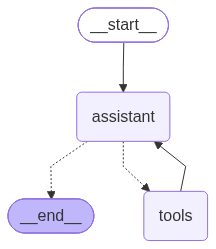

In [28]:
from langgraph.graph import MessagesState, START, StateGraph
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

# Instantiate the graph (we care about states as messages, so we inform LangGraph about it)
builder = StateGraph(MessagesState)

# We add the assistant and tools nodes, and give them a label
builder.add_node('assistant', assistant)
builder.add_node('tools', ToolNode(tools))

# Join the nodes using edges
builder.add_edge(START, 'assistant')  # the entry node is always the special one: 'START', and from there to node 'assistant'
builder.add_conditional_edges("assistant", tools_condition)  # this edge is conditional
'''^Here, `tools_condition` is a special prebuild node --- If the latest message (result) from assistant:
    - is a tool call         -> tools_condition routes to 'tools'
    - is a _not _a tool call -> tools_condition routes to 'END'
'''
builder.add_edge('tools', 'assistant')  # additional edge that always sends _back_ from 'tools' to 'assistant', for a re-evaluation

# Actual build
article_graph = builder.compile()

# Show the compiled graph as a mermaid PNG
display(Image(article_graph.get_graph(xray=True).draw_mermaid_png()))

# Execute Agent

In [29]:
%%time
# Here we place our task to the Agent in natural language
user_prompt = (
    "Explain how to constrain compact dark matter with time-varying quasar equivalent widths.\n"
    "If you are unsure, look for papers more recent than 2023.\n"
    "Respond combining the information you collected from the abstracts you retrieved.\n"
)

# Convert from string to a LangGraph message
user_messages = [HumanMessage(content=user_prompt)]

# Actual agent invocation: this executes the graph
response_messages = article_graph.invoke({'messages': user_messages})

# Check the sequence of performed actions
for m in response_messages['messages']:
    try:
        m.pretty_print()
    except Exception:
        print(str(m))

================================ Human Message =================================

Explain how to constrain compact dark matter with time-varying quasar equivalent widths.
If you are unsure, look for papers more recent than 2023.
Respond combining the information you collected from the abstracts you retrieved.

================================== Ai Message ==================================
Tool Calls:
  arxiv_tool (call_SEH6UtxtrUkwCESdhR2Ct7QN)
 Call ID: call_SEH6UtxtrUkwCESdhR2Ct7QN
  Args:
    query: compact dark matter quasar equivalent widths time-varying equivalent widths quasar microlensing recent 2024 2025
================================= Tool Message =================================
Name: arxiv_tool

[
  {
    "title": "Constraining Compact Dark Matter with Quasar Equivalent Widths from the Sloan Digital Sky Survey Early Data Release",
    "link": "http://arxiv.org/abs/astro-ph/0307465v1",
    "published": "2003-07-27 03:51:42+00:00",
    "abstract": "Cosmologically distribu

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=6>**Exercise — Build a hypothesis-testing agent [40 min]**</font>

**Objective:** Turn a statistical test into a **tool**, and plug it into an Agent that runs the test on demand.

**Task:** Write the tool that performs a 2-sample **Kolmogorov-Smirnov (K-S) test**, then let the Agent call it.

</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

The user will ask the following question:

</div>

In [35]:
user_prompt = (
    "I have two samples of a measured quantity.\n"
    "Sample A: [10.0, 10.3, 9.73, 9.11, 9.55, 9.01, 10.06, 11.34, 9.51]\n"
    "Sample B: [11.26, 12.59, 12.43, 12.13, 10.88, 11.96, 12.83, 10.39, 11.45]\n"
    "Check whether they come from the same distribution.\n"
)


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task A**: Prepare the tool.

1. **Write** a function `ks_tool` that:
   - Takes 2 lists (samples) as inputs
   - Uses `stats.ks_2samp` from `scipy.stats`
   - Returns the p-value.
2. Write an accurate **docstring** that says what the tool does and what it returns: the Agent reads it to decide when to call the tool.
3. **Test** your tool directly on 2 validation samples.
4. **Run** the pre-filled cells to link the tool.
</div>

In [70]:
from scipy import stats
import json

def ks_tool(sample_a: list[float], sample_b: list[float]) -> str:
    """Run a 2-sample Kolmogorov-Smirnov test and report the outcome.

    Parameters
    ----------
    sample_a : list of float
        First sample of measurements.
    sample_b : list of float
        Second sample of measurements.
    Returns
    -------
    str
        JSON-formatted string with the D-statistic and the p-value of the
        2-sample Kolmogorov-Smirnov test comparing the two samples.
    """

    # Run the 2-sample KS test from scipy: it returns the D-statistic and the p-value.
    result = stats.ks_2samp(sample_a, sample_b)

    # Convert to plain Python floats so they can be serialised to JSON.
    d_statistic = float(result.statistic)
    p_value = float(result.pvalue)

    output = {
        "d_statistic": d_statistic,
        "p_value": p_value,
    }

    return json.dumps(output, indent=2)

In [71]:
tools = [ks_tool]

llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task B**: Write a proper `sys_msg` for the Agent — it must provide the rule.

**Hint**: Basically, you have to instruct the Agnet to use the KS test and decide based on some threshold $\alpha$.

</div>

In [72]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage

def assistant(state: MessagesState):
    sys_msg = SystemMessage(content=
        'You are an assistant specialized in astrophysics and statistics.' \
        'You may call the Kolmogorov-Smirnov test tool when helpful and should otherwise' \
        'answer directly. Use a significance level of 0.05.')

    return {'messages': [llm_with_tools.invoke([sys_msg] + state['messages'])]}


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task C**: Just run the cells below to assess your Agent.

Iterate the previous steps until satisfied.

</div>

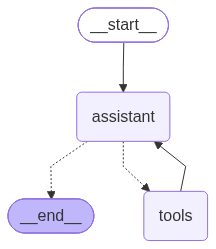

In [73]:
from langgraph.graph import MessagesState, START, StateGraph
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

builder = StateGraph(MessagesState)

builder.add_node('assistant', assistant)
builder.add_node('tools', ToolNode(tools))

builder.add_edge(START, 'assistant')
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge('tools', 'assistant')

ks_graph = builder.compile()

display(Image(ks_graph.get_graph(xray=True).draw_mermaid_png()))


In [83]:
np.random.seed(42)
sample_a = np.random.normal(10, 1, 20)
sample_b = np.random.normal(13, 1, 20)
print(sample_a)
print(sample_b)

[10.49671415  9.8617357  10.64768854 11.52302986  9.76584663  9.76586304
 11.57921282 10.76743473  9.53052561 10.54256004  9.53658231  9.53427025
 10.24196227  8.08671976  8.27508217  9.43771247  8.98716888 10.31424733
  9.09197592  8.5876963 ]
[14.46564877 12.7742237  13.0675282  11.57525181 12.45561728 13.11092259
 11.84900642 13.37569802 12.39936131 12.70830625 12.39829339 14.85227818
 12.98650278 11.94228907 13.82254491 11.77915635 13.2088636  11.04032988
 11.67181395 13.19686124]


In [ ]:
Sample A: [10.49671415  9.8617357  10.64768854 11.52302986  9.76584663  9.76586304 11.57921282 10.76743473  9.53052561 10.54256004  9.53658231  9.53427025 10.24196227  8.08671976  8.27508217  9.43771247  8.98716888 10.31424733 9.09197592  8.5876963 ]
Sample B: [14.46564877 12.7742237  13.0675282  11.57525181 12.45561728 13.11092259 11.84900642 13.37569802 12.39936131 12.70830625 12.39829339 14.85227818 12.98650278 11.94228907 13.82254491 11.77915635 13.2088636  11.04032988 11.67181395 13.19686124]

In [84]:
user_prompt_test = (
    "I have two samples of a measured quantity.\n"
    "Sample A: [10.49671415  9.8617357  10.64768854 11.52302986  9.76584663  9.76586304 11.57921282 10.76743473  9.53052561 10.54256004  9.53658231  9.53427025 10.24196227  8.08671976  8.27508217  9.43771247  8.98716888 10.31424733 9.09197592  8.5876963 ]\n"
    "Sample B: [14.46564877 12.7742237  13.0675282  11.57525181 12.45561728 13.11092259 11.84900642 13.37569802 12.39936131 12.70830625 12.39829339 14.85227818 12.98650278 11.94228907 13.82254491 11.77915635 13.2088636  11.04032988 11.67181395 13.19686124]\n"
    "Check whether they come from the same distribution.\n"
    "If they come from different distributions, then please match the mean value by translation.\n"
)

In [85]:
%%time
# user_messages = [HumanMessage(content=user_prompt)]
user_messages = [HumanMessage(content=user_prompt_test)]

response_messages = ks_graph.invoke({'messages': user_messages})

for m in response_messages['messages']:
    try:
        m.pretty_print()
    except Exception:
        print(str(m))


================================ Human Message =================================

I have two samples of a measured quantity.
Sample A: [10.49671415  9.8617357  10.64768854 11.52302986  9.76584663  9.76586304 11.57921282 10.76743473  9.53052561 10.54256004  9.53658231  9.53427025 10.24196227  8.08671976  8.27508217  9.43771247  8.98716888 10.31424733 9.09197592  8.5876963 ]
Sample B: [14.46564877 12.7742237  13.0675282  11.57525181 12.45561728 13.11092259 11.84900642 13.37569802 12.39936131 12.70830625 12.39829339 14.85227818 12.98650278 11.94228907 13.82254491 11.77915635 13.2088636  11.04032988 11.67181395 13.19686124]
Check whether they come from the same distribution.
If they come from different distributions, then please match the mean value by translation.

================================== Ai Message ==================================
Tool Calls:
  ks_tool (call_wzMRH9v2kRhTDgQSMWcaaOOQ)
 Call ID: call_wzMRH9v2kRhTDgQSMWcaaOOQ
  Args:
    sample_a: [10.49671415, 9.8617357, 10.64

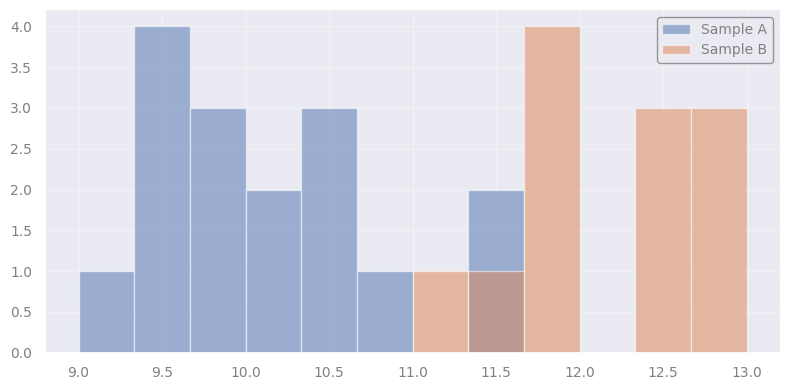

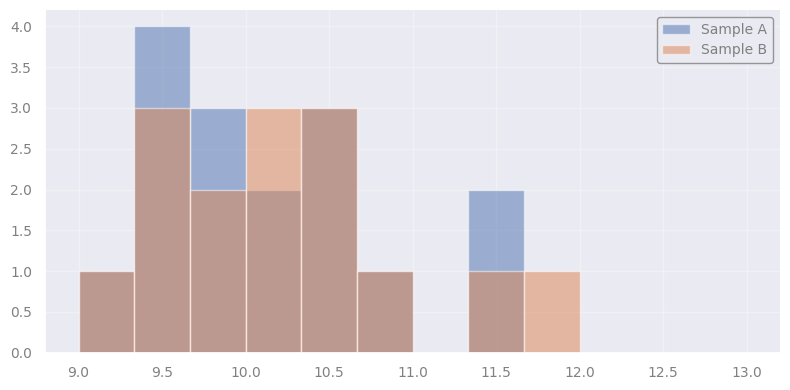

In [87]:
# sample_a = [10.0, 10.3, 9.73, 9.11, 9.55, 9.01, 10.06, 11.34, 9.51]
# sample_b = [11.26, 12.59, 12.43, 12.13, 10.88, 11.96, 12.83, 10.39, 11.45]

import numpy as np
plt.hist(sample_a, bins=np.linspace(9, 13, 13), alpha=0.5, label='Sample A')
plt.hist(sample_b, bins=np.linspace(9, 13, 13), alpha=0.5, label='Sample B')
plt.legend(loc='upper right')
plt.show()

plt.hist(sample_a, bins=np.linspace(9, 13, 13), alpha=0.5, label='Sample A')
plt.hist(sample_b - 2.862, bins=np.linspace(9, 13, 13), alpha=0.5, label='Sample B')
plt.legend(loc='upper right')
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task D [optional]**: Edit the `user_prompt` slightly, and test if your Agent is solid with respect to prompt variations.

</div>

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[Solution below]</b>

</div>

In [ ]:
from scipy import stats
import json

def ks_tool(sample_a: list[float], sample_b: list[float]) -> str:
    """Run a 2-sample Kolmogorov-Smirnov test and report the outcome.

    Parameters
    ----------
    sample_a : list of float
        First sample of measurements.
    sample_b : list of float
        Second sample of measurements.
    Returns
    -------
    str
        JSON-formatted string with the D-statistic and the p-value of the
        2-sample Kolmogorov-Smirnov test comparing the two samples.
    """

    # Run the 2-sample KS test from scipy: it returns the D-statistic and the p-value.
    result = stats.ks_2samp(sample_a, sample_b)

    # Convert to plain Python floats so they can be serialised to JSON.
    d_statistic = float(result.statistic)
    p_value = float(result.pvalue)

    output = {
        "d_statistic": d_statistic,
        "p_value": p_value,
    }

    return json.dumps(output, indent=2)


In [ ]:
tools = [ks_tool]

llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)


In [ ]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage

def assistant(state: MessagesState):
    sys_msg = SystemMessage(content=
        'You are an assistant specialized in astrophysics and statistics.' \
        'You may call the Kolmogorov-Smirnov test tool when helpful and should otherwise' \
        'answer directly. Use a significance level of 0.05.')

    return {'messages': [llm_with_tools.invoke([sys_msg] + state['messages'])]}


In [ ]:
from langgraph.graph import MessagesState, START, StateGraph
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

builder = StateGraph(MessagesState)

builder.add_node('assistant', assistant)
builder.add_node('tools', ToolNode(tools))

builder.add_edge(START, 'assistant')
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge('tools', 'assistant')

ks_graph = builder.compile()

display(Image(ks_graph.get_graph(xray=True).draw_mermaid_png()))


In [ ]:
%%time
user_messages = [HumanMessage(content=user_prompt)]

response_messages = ks_graph.invoke({'messages': user_messages})

for m in response_messages['messages']:
    try:
        m.pretty_print()
    except Exception:
        print(str(m))


<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[End of solution]</b>

</div>

In [ ]:
#EOF